## Introduction
---
* Import necessary libraries and load data

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../../datasets/raw/spaceship_train.csv')
print(df.shape)

(8693, 14)


* Data Inspection

In [34]:
def inspect_data(df):
    print(f"Columns: \n{df.columns}")
    print(f"Dataframe Info: \n{df.info()}")
    print(f"\nDescriptive Statistics: \n{df.describe().T}")
    print(f"\nMissing Values: \n{df.isnull().sum()}")
    print(f"\nUnique Values: \n{df.nunique()}")
    print(f"\nDuplicated Rows: \n{df.duplicated().sum()}")

In [35]:
inspect_data(df)

Columns: 
Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
d

## Univariate Analysis
---
* Target variable

Transported
True     4378
False    4315
Name: count, dtype: int64


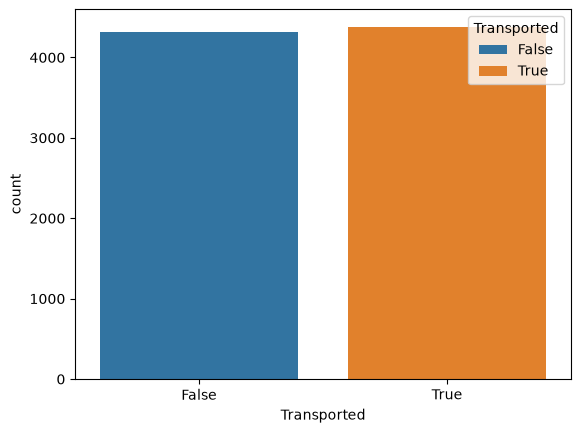

In [21]:
transported = df['Transported'].value_counts()
print(transported)

sns.countplot(data=df, x='Transported', hue='Transported')
plt.show()

*The classes are fairly balanced hence no need for class balancing techniques and accuracy is a reasonable initial evaluation metric.*

* Categorical and Boolean features

In [30]:
grouped = df[["HomePlanet", "CryoSleep", "Destination", "VIP"]]

for col in grouped:
    print(f"\nValue Counts for {col}:")
    print(df[col].value_counts())


Value Counts for HomePlanet:
HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64

Value Counts for CryoSleep:
CryoSleep
False    5439
True     3037
Name: count, dtype: int64

Value Counts for Destination:
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64

Value Counts for VIP:
VIP
False    8291
True      199
Name: count, dtype: int64


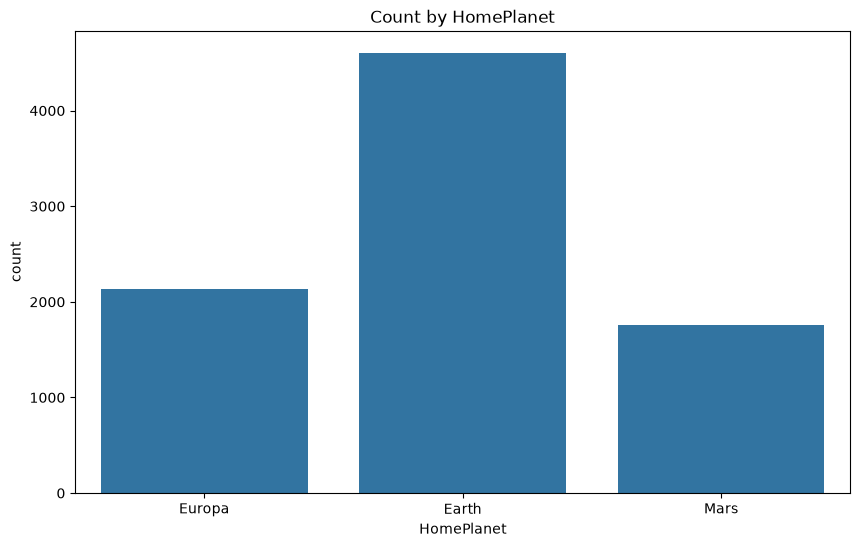

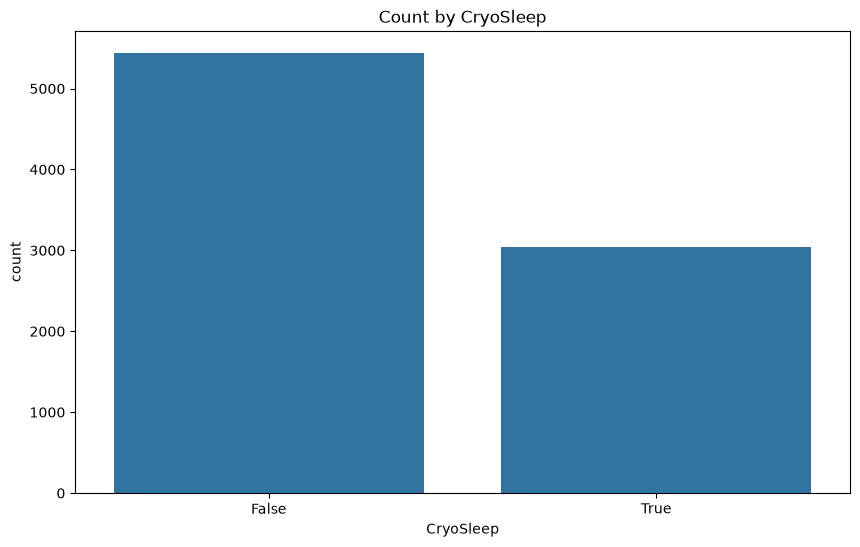

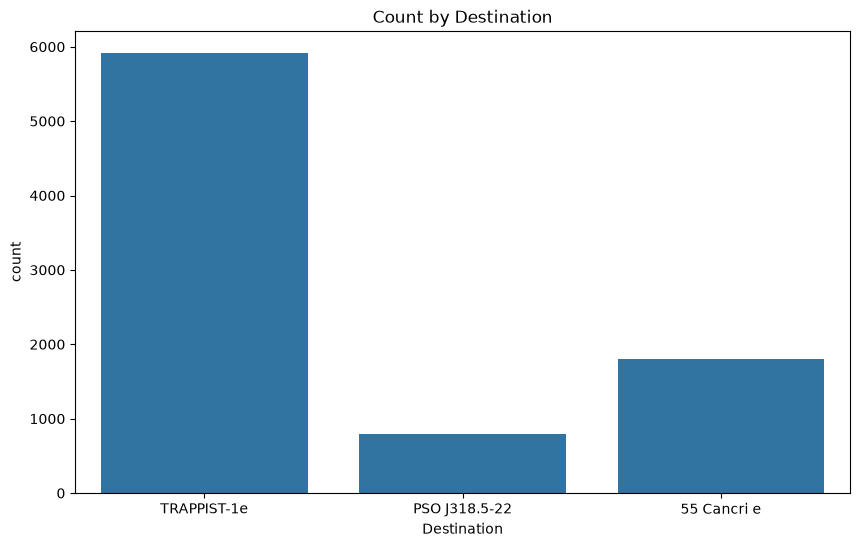

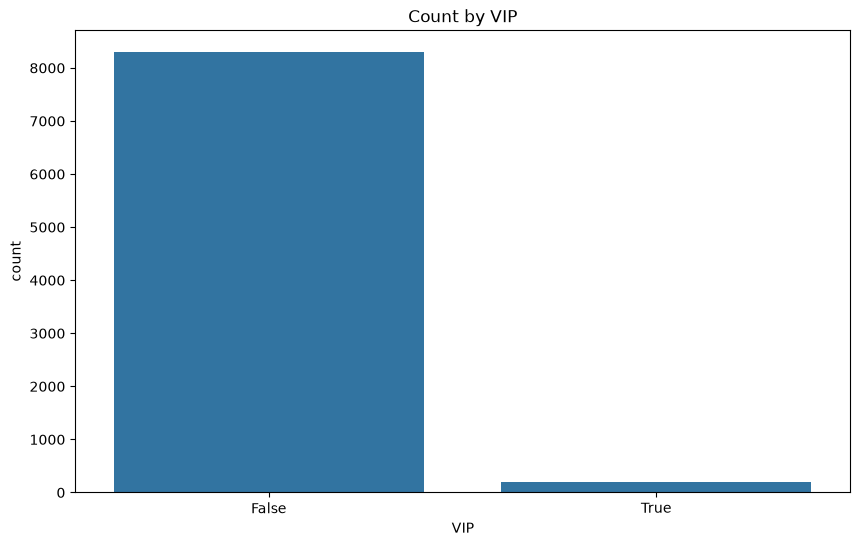

In [31]:
for col in grouped:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f"Count by {col}")
    plt.show()


* Numerical statistics

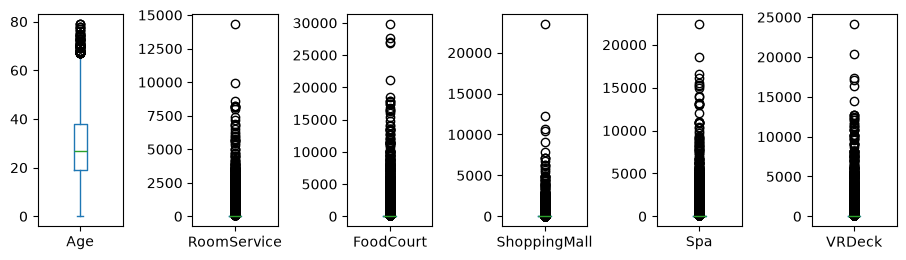

In [22]:
numerical_cols = df.select_dtypes(include="number")

numerical_cols.plot(
    kind="box",
    subplots=True,
    layout=(8, 13),
    figsize=(20, 20)
)

plt.tight_layout()
plt.show()

*Most passengers are young adults which may be associated with the probability of being transported. While when it comes to spending, most passengers didn’t spend much, but a few spent heavily*

## Bivariate Analysis
---
* Categorical features versus Transported

In [41]:
features = ["HomePlanet", "CryoSleep", "Destination", "VIP"]

for feature in features:
    print(f"\n--- {feature} vs Transported ---")
    print(pd.crosstab(df[feature], df["Transported"], dropna = False))

    print("\nTransportation rate by category:")
    print(
        df.groupby(feature, dropna=False)["Transported"]
        .agg(["mean", "count"])
    )



--- HomePlanet vs Transported ---
Transported  False  True 
HomePlanet               
Earth         2651   1951
Europa         727   1404
Mars           839    920
NaN             98    103

Transportation rate by category:
                mean  count
HomePlanet                 
Earth       0.423946   4602
Europa      0.658846   2131
Mars        0.523024   1759
NaN         0.512438    201

--- CryoSleep vs Transported ---
Transported  False  True 
CryoSleep                
False         3650   1789
True           554   2483
NaN            111    106

Transportation rate by category:
               mean  count
CryoSleep                 
False      0.328921   5439
True       0.817583   3037
NaN        0.488479    217

--- Destination vs Transported ---
Transported    False  True 
Destination                
55 Cancri e      702   1098
PSO J318.5-22    395    401
TRAPPIST-1e     3128   2787
NaN               90     92

Transportation rate by category:
                   mean  count
Desti

* Age vs Transported

In [ ]:
age_bins = [0, 18, 30, 50, 70, 100]
age_labels = ["Child", "Young Adult", "Adult", "Middle-aged", "Senior"]

age_groups = pd.cut(df["Age"], bins=age_bins, labels=age_labels)

age_trans = ([
    df.groupby(age_groups)["Transported"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "Transportation Rate", "count": "Count"})
])

print("\nTransportation rate by age group:\n", age_trans)


Transportation rate by age group:
              Transportation Rate  Count
Age                                    
Child                   0.586248   1687
Young Adult             0.468190   3238
Adult                   0.479432   2674
Middle-aged             0.490000    700
Senior                  0.378378     37


* Numerical features vs Transported

* Zero Spending Transportation rate

In [55]:
spending_features = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

for feature in spending_features:
    print(f"\n--- {feature} ---")
    print(
        df.groupby("Transported")[feature]
        .apply(lambda x: (x == 0).mean())
    )


--- RoomService ---
Transported
False    0.473928
True     0.806761
Name: RoomService, dtype: float64

--- FoodCourt ---
Transported
False    0.517265
True     0.736409
Name: FoodCourt, dtype: float64

--- ShoppingMall ---
Transported
False    0.519583
True     0.764048
Name: ShoppingMall, dtype: float64

--- Spa ---
Transported
False    0.445191
True     0.777296
Name: Spa, dtype: float64

--- VRDeck ---
Transported
False    0.473696
True     0.788259
Name: VRDeck, dtype: float64


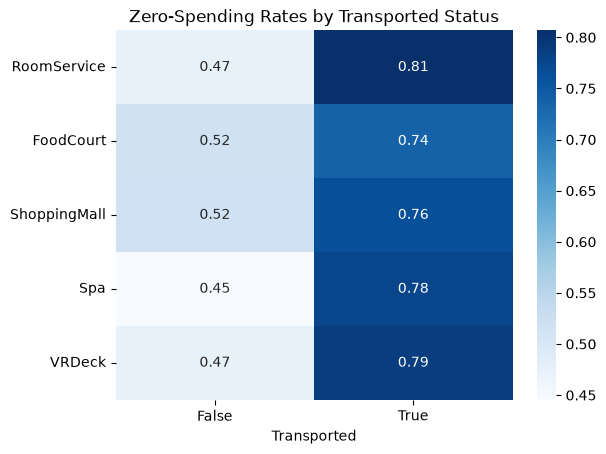

In [61]:
zero_rates = {}
for feature in spending_features:
    zero_rates[feature] = df.groupby("Transported")[feature].apply(lambda x: (x==0).mean())

zero_df = pd.DataFrame(zero_rates).T
sns.heatmap(zero_df, annot=True, cmap="Blues", fmt=".2f")
plt.title("Zero-Spending Rates by Transported Status")
plt.show()

*Transported passengers are consistently more likely to have spent nothing across all amenities. This associates that non‑spending behavior is is an indicator of transport likelihood, while spending amounts themselves are less informative due to skew and outliers*